In [8]:
import pandas as pd
import floris
import numpy as np
import matplotlib.pyplot as plt
from floris import FlorisModel
from pyproj import Proj

print(f"FLORIS version: {floris.__version__}")

FLORIS version: 4.6.4


In [9]:
# Load real turbine coordinates
static = pd.read_csv('../data/raw/Kelmarsh_WT_static.csv')
static[['Title', 'Latitude', 'Longitude', 'Hub Height (m)', 'Rotor Diameter (m)']]

,Title,Latitude,Longitude,Hub Height (m),Rotor Diameter (m)
0,Kelmarsh 1,52.400604,-0.947133,78.5,92
1,Kelmarsh 2,52.402551,-0.949527,78.5,92
2,Kelmarsh 3,52.403834,-0.944190,68.5,92
3,Kelmarsh 4,52.398781,-0.941150,78.5,92
4,Kelmarsh 5,52.402308,-0.940537,78.5,92
5,Kelmarsh 6,52.400687,-0.936093,68.5,92


In [10]:
# Project to UTM Zone 30N (appropriate for UK)
proj = Proj(proj='utm', zone=30, ellps='WGS84')

easting, northing = proj(static['Longitude'].values, static['Latitude'].values)

# Convert to local coordinates (relative to first turbine)
x = easting - easting.min()
y = northing - northing.min()

for i, row in static.iterrows():
    print(f"T{i+1}: x={x[i]:.1f}m, y={y[i]:.1f}m, hub_height={row['Hub Height (m)']}m")

T1: x=169.0m, y=191.2m, hub_height=78.5m
T2: x=0.0m, y=403.1m, hub_height=78.5m
T3: x=359.0m, y=556.1m, hub_height=68.5m
T4: x=581.8m, y=0.0m, hub_height=78.5m
T5: x=612.3m, y=393.4m, hub_height=78.5m
T6: x=919.7m, y=221.8m, hub_height=68.5m


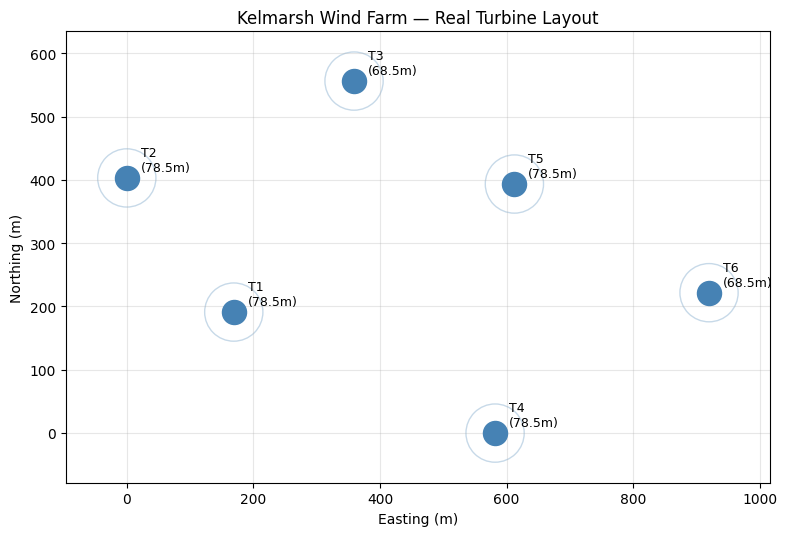

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(x, y, s=300, color='steelblue', zorder=5)
for i in range(len(x)):
    ax.annotate(f'T{i+1}\n({static["Hub Height (m)"].iloc[i]}m)', 
                (x[i], y[i]), 
                textcoords='offset points',
                xytext=(10, 5), fontsize=9)

# Draw rotor diameter to scale
for i in range(len(x)):
    circle = plt.Circle((x[i], y[i]), 46, fill=False, 
                         color='steelblue', alpha=0.3, linewidth=1)
    ax.add_patch(circle)

ax.set_title('Kelmarsh Wind Farm — Real Turbine Layout')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/08_turbine_layout.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Load clean SCADA data
df_scada = pd.read_csv('../data/processed/turbine1_clean.csv',
                       index_col='timestamp', parse_dates=True)

# Bin wind speed into 0.5 m/s bins and compute mean power per bin
df_scada['ws_bin'] = (df_scada['wind_speed'] / 0.5).round() * 0.5

power_curve = df_scada.groupby('ws_bin')['power'].agg(['mean', 'std', 'count'])
power_curve = power_curve[power_curve['count'] > 10]  # min 10 samples per bin
power_curve.columns = ['power_kw', 'power_std', 'count']

print(power_curve[['power_kw', 'count']].round(1))

        power_kw  count
ws_bin                 
2.0         11.9    112
2.5         18.6    749
3.0         33.6   1920
3.5         68.1   2330
4.0        114.1   2696
4.5        171.4   2993
5.0        241.5   3159
5.5        330.4   3434
6.0        439.6   3637
6.5        564.8   3560
7.0        717.5   3403
7.5        880.9   2977
8.0       1071.1   2509
8.5       1268.1   2022
9.0       1466.2   1903
9.5       1659.3   1726
10.0      1813.5   1508
10.5      1915.8   1324
11.0      1972.3   1112
11.5      2004.6    829
12.0      2024.3    640
12.5      2035.3    480
13.0      2041.2    381
13.5      2044.7    296
14.0      2038.6    262
14.5      2044.0    190
15.0      2041.1    144
15.5      2046.1    114
16.0      2042.3     77
16.5      2036.5     67
17.0      2020.7     38
17.5      1940.5     34
18.0      1947.8     24
18.5      1976.7     14


In [33]:
import numpy as np

# Estimate Ct from power using actuator disk theory
# P = 0.5 * rho * A * Cp * v^3
# Ct = 4a(1-a) where Cp = 4a(1-a)^2, solved numerically

rho = 1.225  # air density kg/m3
R = 46.0     # rotor radius m (92m diameter)
A = np.pi * R**2  # rotor area m2

def cp_from_power(power_kw, wind_speed):
    """Calculate Cp from measured power and wind speed"""
    P = power_kw * 1000  # W
    P_wind = 0.5 * rho * A * wind_speed**3
    return np.clip(P / P_wind, 0, 0.593)  # cap at Betz limit

def ct_from_cp(cp):
    """Estimate Ct from Cp using actuator disk theory"""
    # Cp = 4a(1-a)^2, Ct = 4a(1-a)
    # Solve for induction factor a numerically
    a = np.clip(0.5 * (1 - np.sqrt(1 - cp * (27/16))), 0, 0.5)
    return 4 * a * (1 - a)

ws = power_curve.index.values
cp_values = cp_from_power(power_curve['power_kw'].values, ws)
ct_values = ct_from_cp(cp_values)

power_curve['cp'] = cp_values
power_curve['ct'] = ct_values

print(power_curve[['power_kw', 'cp', 'ct']].round(3))

        power_kw     cp     ct
ws_bin                        
2.0       11.904  0.365  0.617
2.5       18.649  0.293  0.495
3.0       33.563  0.305  0.515
3.5       68.074  0.390  0.658
4.0      114.077  0.438  0.739
4.5      171.359  0.462  0.779
5.0      241.538  0.475  0.801
5.5      330.427  0.488  0.823
6.0      439.621  0.500  0.844
6.5      564.822  0.505  0.852
7.0      717.468  0.514  0.867
7.5      880.883  0.513  0.865
8.0     1071.120  0.514  0.867
8.5     1268.124  0.507  0.856
9.0     1466.230  0.494  0.834
9.5     1659.295  0.475  0.802
10.0    1813.465  0.445  0.752
10.5    1915.790  0.406  0.686
11.0    1972.307  0.364  0.614
11.5    2004.580  0.324  0.546
12.0    2024.300  0.288  0.486
12.5    2035.319  0.256  0.432
13.0    2041.230  0.228  0.385
13.5    2044.712  0.204  0.344
14.0    2038.580  0.182  0.308
14.5    2043.953  0.165  0.278
15.0    2041.141  0.149  0.251
15.5    2046.130  0.135  0.228
16.0    2042.318  0.122  0.207
16.5    2036.541  0.111  0.188
17.0    

In [34]:
# Prepare wind speed and curve arrays for YAML
# Add cut-in and cut-out points
ws_list = [0.0, 1.9] + ws.tolist() + [19.0, 25.0, 25.1, 50.0]
power_list = [0.0, 0.0] + power_curve['power_kw'].tolist() + [0.0, 0.0, 0.0, 0.0]
ct_list = [0.0, 0.0] + ct_values.tolist() + [0.08, 0.08, 0.0, 0.0]

mm92_empirical = f"""# Senvion MM92 2050 kW wind turbine
# Power curve and Ct derived empirically from Kelmarsh SCADA data (2020)
# Ct estimated from Cp via actuator disk theory

turbine_type: 'senvion_mm92'
hub_height: 78.5
rotor_diameter: 92.0
TSR: 8.0
operation_model: 'cosine-loss'

power_thrust_table:
  ref_air_density: 1.225
  ref_tilt: 5.0
  cosine_loss_exponent_tilt: 1.88
  cosine_loss_exponent_yaw: 1.88
  wind_speed: {ws_list}
  power: {[round(p, 2) for p in power_list]}
  thrust_coefficient: {[round(c, 3) for c in ct_list]}
"""

with open('../data/turbine_library/senvion_mm92.yaml', 'w') as f:
    f.write(mm92_empirical)

print("MM92 empirical turbine config saved ✅")

MM92 empirical turbine config saved ✅


In [35]:
import yaml
from pathlib import Path

# Load and modify the default config
with open('../data/kelmarsh_floris.yaml', 'r') as f:
    config = yaml.safe_load(f)

# Update layout with real Kelmarsh coordinates
config['farm']['layout_x'] = x.tolist()
config['farm']['layout_y'] = y.tolist()
config['farm']['turbine_type'] = ['senvion_mm92'] * 6
config['farm']['turbine_library_path'] = str(Path('../data/turbine_library').resolve())

# Update flow field
config['flow_field']['wind_speeds'] = [9.0]
config['flow_field']['wind_directions'] = [225.0]
config['flow_field']['turbulence_intensities'] = [0.06]

# Save modified config
with open('../data/kelmarsh_floris_configured.yaml', 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

# Initialize FLORIS
fmodel = FlorisModel('../data/kelmarsh_floris_configured.yaml')

print("FLORIS model initialized ✅")
print(f"Number of turbines: {fmodel.n_turbines}")

FLORIS model initialized ✅
Number of turbines: 6


In [45]:
fmodel.run()

turbine_powers = fmodel.get_turbine_powers() / 1000  # W to kW

print("Turbine powers at 9 m/s from SW (225°):")
for i, p in enumerate(turbine_powers[0]):
    print(f"  T{i+1}: {p:.1f} kW")

total = turbine_powers[0].sum()

# Get no-wake power from empirical curve at 9 m/s
no_wake_single = power_curve.loc[9.0, 'power_kw']
no_wake = no_wake_single * 6

print(f"\nTotal farm power: {total:.1f} kW")
print(f"No-wake power:    {no_wake:.1f} kW")
print(f"Wake loss:        {(1 - total / no_wake)*100:.1f}%")

Turbine powers at 9 m/s from SW (225°):
  T1: 2023.2 kW
  T2: 2023.2 kW
  T3: 2023.1 kW
  T4: 2023.2 kW
  T5: 2023.2 kW
  T6: 2016.2 kW

Total farm power: 12132.1 kW
No-wake power:    8797.4 kW
Wake loss:        -37.9%


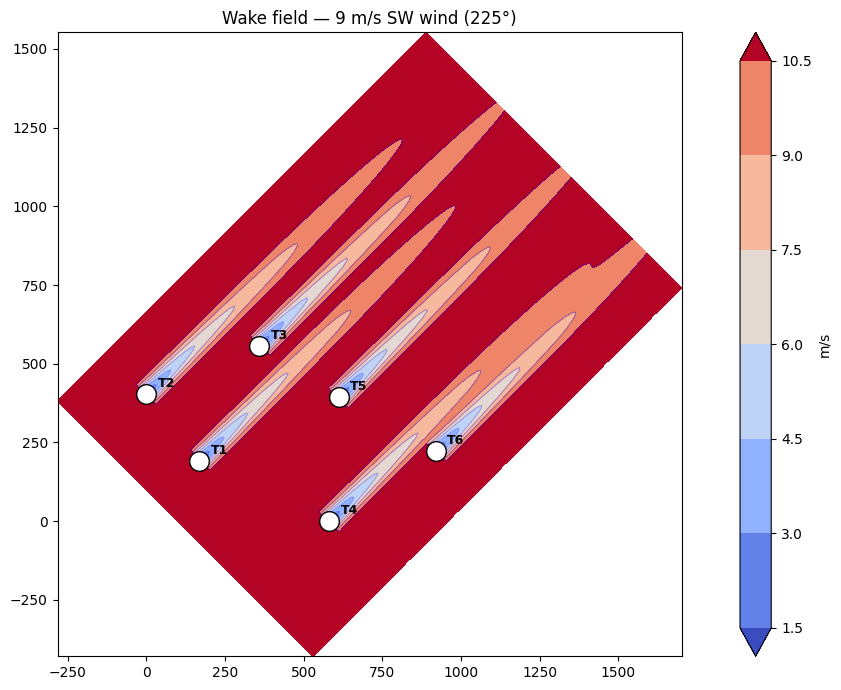

In [62]:
from floris.flow_visualization import visualize_cut_plane

fig, ax = plt.subplots(figsize=(12, 7))

horizontal_plane = fmodel.calculate_horizontal_plane(height=78.5)
visualize_cut_plane(horizontal_plane, ax=ax, 
                    title='Wake field — 9 m/s SW wind (225°)',
                    color_bar=True)

# Overlay turbine positions
ax.scatter(x, y, s=200, c='white', edgecolors='black', zorder=5)
for i in range(len(x)):
    ax.annotate(f'T{i+1}', (x[i], y[i]), 
                textcoords='offset points',
                xytext=(8, 5), fontsize=9, 
                fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plots/09_wake_field.png', dpi=150, bbox_inches='tight')
plt.show()

In [63]:
from floris.optimization.yaw_optimization.yaw_optimizer_sr import YawOptimizationSR

# Reset to 9 m/s SW wind
fmodel.set(
    wind_speeds=[9.0],
    wind_directions=[225.0],
    turbulence_intensities=[0.06]
)

# Run baseline (no yaw offset)
fmodel.run()
baseline_power = fmodel.get_farm_power() / 1000  # kW

# Run yaw optimization
yaw_opt = YawOptimizationSR(fmodel)
df_opt = yaw_opt.optimize()

print("Optimal yaw offsets (degrees):")
print(df_opt[['wind_direction', 'wind_speed', 'yaw_angles_opt']])

print(f"\nBaseline farm power:  {baseline_power[0]:.1f} kW")
print(f"Optimized farm power: {df_opt['farm_power_opt'].values[0]/1000:.1f} kW")
print(f"AEP gain:             {(df_opt['farm_power_opt'].values[0]/1000 / baseline_power[0] - 1)*100:.2f}%")

[Serial Refine] Processing pass=0, turbine_depth=0 (0.0%)
[Serial Refine] Processing pass=0, turbine_depth=1 (8.3%)
[Serial Refine] Processing pass=0, turbine_depth=2 (16.7%)
[Serial Refine] Processing pass=0, turbine_depth=3 (25.0%)
[Serial Refine] Processing pass=0, turbine_depth=4 (33.3%)
[Serial Refine] Processing pass=0, turbine_depth=5 (41.7%)
[Serial Refine] Processing pass=1, turbine_depth=0 (50.0%)
[Serial Refine] Processing pass=1, turbine_depth=1 (58.3%)
[Serial Refine] Processing pass=1, turbine_depth=2 (66.7%)
[Serial Refine] Processing pass=1, turbine_depth=3 (75.0%)
[Serial Refine] Processing pass=1, turbine_depth=4 (83.3%)
[Serial Refine] Processing pass=1, turbine_depth=5 (91.7%)
Optimal yaw offsets (degrees):
   wind_direction  wind_speed                  yaw_angles_opt
0           225.0         9.0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Baseline farm power:  8604.5 kW
Optimized farm power: 8604.5 kW
AEP gain:             0.00%


In [65]:
wind_dirs = [180, 200, 210, 220, 225, 240, 270]

results = []
for wd in wind_dirs:
    fmodel.set(
        wind_speeds=[9.0],
        wind_directions=[float(wd)],
        turbulence_intensities=[0.06]
    )
    fmodel.run()
    baseline = fmodel.get_farm_power()[0] / 1000
    
    yaw_opt = YawOptimizationSR(fmodel)
    df_opt = yaw_opt.optimize()
    optimized = df_opt['farm_power_opt'].values[0] / 1000
    gain = (optimized / baseline - 1) * 100
    
    results.append({'wind_dir': wd, 'baseline_kw': baseline, 
                    'optimized_kw': optimized, 'gain_pct': gain})
    print(f"WD={wd}°: baseline={baseline:.0f} kW, optimized={optimized:.0f} kW, gain={gain:.2f}%")

[Serial Refine] Processing pass=0, turbine_depth=0 (0.0%)
[Serial Refine] Processing pass=0, turbine_depth=1 (8.3%)
[Serial Refine] Processing pass=0, turbine_depth=2 (16.7%)
[Serial Refine] Processing pass=0, turbine_depth=3 (25.0%)
[Serial Refine] Processing pass=0, turbine_depth=4 (33.3%)
[Serial Refine] Processing pass=0, turbine_depth=5 (41.7%)
[Serial Refine] Processing pass=1, turbine_depth=0 (50.0%)
[Serial Refine] Processing pass=1, turbine_depth=1 (58.3%)
[Serial Refine] Processing pass=1, turbine_depth=2 (66.7%)
[Serial Refine] Processing pass=1, turbine_depth=3 (75.0%)
[Serial Refine] Processing pass=1, turbine_depth=4 (83.3%)
[Serial Refine] Processing pass=1, turbine_depth=5 (91.7%)
WD=180°: baseline=7838 kW, optimized=7838 kW, gain=0.00%
[Serial Refine] Processing pass=0, turbine_depth=0 (0.0%)
[Serial Refine] Processing pass=0, turbine_depth=1 (8.3%)
[Serial Refine] Processing pass=0, turbine_depth=2 (16.7%)
[Serial Refine] Processing pass=0, turbine_depth=3 (25.0%)
[Se

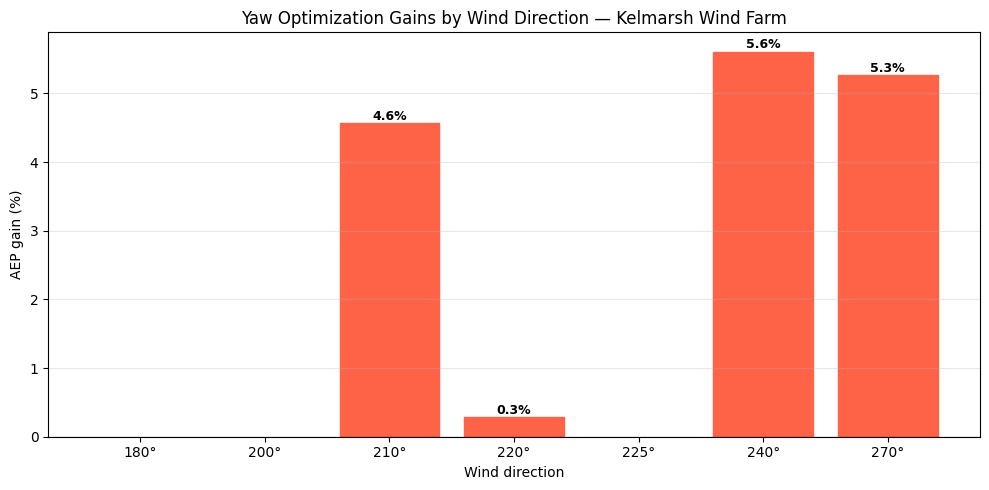

In [66]:
import pandas as pd

df_results = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))

x_pos = range(len(df_results))
bars = ax.bar(x_pos, df_results['gain_pct'], color='steelblue', edgecolor='white')

# Highlight positive gains
for bar, gain in zip(bars, df_results['gain_pct']):
    if gain > 0:
        bar.set_color('tomato')

ax.set_xticks(x_pos)
ax.set_xticklabels([f"{wd}°" for wd in df_results['wind_dir']])
ax.set_xlabel('Wind direction')
ax.set_ylabel('AEP gain (%)')
ax.set_title('Yaw Optimization Gains by Wind Direction — Kelmarsh Wind Farm')
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(axis='y', alpha=0.3)

for bar, gain in zip(bars, df_results['gain_pct']):
    if gain > 0:
        ax.text(bar.get_x() + bar.get_width()/2, gain + 0.05,
                f'{gain:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plots/10_yaw_optimization.png', dpi=150, bbox_inches='tight')
plt.show()